In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.analysis.ip_results import load_results_parquet
from src.analysis.ip_results import profit_summary_for_scenario, infer_perfect_foresight_path
import pandas as pd
import numpy as np


df, run_meta = load_results_parquet(f'{PROJECT_ROOT}/results/ip_rolling_prob/ip_rolling_prob_qr_quantile_paths_cvar_a0p95_l0p1_TP_L1_0.1_CP_0_v1.parquet')


In [2]:



ce_dir = PROJECT_ROOT / "results/ip_rolling_ce"
prob_dir = PROJECT_ROOT / "results/ip_rolling_prob"

rows = []

# Deterministic CE (forecast + perfect foresight)
for p in sorted(ce_dir.glob("*.parquet")):
    if "deterministic_forecast" not in p.name:
        continue
    pf = infer_perfect_foresight_path(p)
    series, totals, meta = profit_summary_for_scenario(p, perfect_foresight_path=pf)

    rows.append({
        "file": p.name,
        "kind": "deterministic",
        "profit_forecast_total_eur": totals.forecast_total_eur,
        "profit_realized_total_eur": totals.realized_total_eur,
        "profit_optimal_total_eur": totals.optimal_total_eur,
        "realized/optimal": round(totals.realized_total_eur/totals.optimal_total_eur, 3) if totals.optimal_total_eur is not None else np.nan,
        "regret_vs_optimal_eur": (totals.optimal_total_eur - totals.realized_total_eur) if totals.optimal_total_eur is not None else np.nan,
    })

# Probabilistic (forecast + realized, no optimal)
for p in sorted(prob_dir.glob("*.parquet")):
    series, totals, meta = profit_summary_for_scenario(p)

    rows.append({
        "file": p.name,
        "kind": "probabilistic",
        "profit_forecast_total_eur": totals.forecast_total_eur,
        "profit_realized_total_eur": totals.realized_total_eur,
        "forecast/optimal":np.nan,
        "realized/optimal":np.nan,
        "profit_optimal_total_eur": np.nan,
        "regret_vs_optimal_eur": np.nan,
    })

summary = pd.DataFrame(rows).sort_values(["kind", "profit_realized_total_eur"], ascending=[True, False])
summary.head(20)


,file,kind,profit_forecast_total_eur,profit_realized_total_eur,profit_optimal_total_eur,realized/optimal,regret_vs_optimal_eur,forecast/optimal
3,ip_rolling_ce_qr_deterministic_forecast_TP_L1_...,deterministic,1.733467e+06,1.294757e+06,2.478109e+06,0.522,1.183351e+06,NaN
4,ip_rolling_ce_qr_deterministic_forecast_TP_L2_...,deterministic,1.730928e+06,1.293504e+06,2.473287e+06,0.523,1.179783e+06,NaN
5,ip_rolling_ce_qr_deterministic_forecast_TP_L2_...,deterministic,1.729874e+06,1.292721e+06,2.467569e+06,0.524,1.174848e+06,NaN
6,ip_rolling_ce_qr_deterministic_forecast_TP_L2_...,deterministic,1.729543e+06,1.292547e+06,2.465595e+06,0.524,1.173048e+06,NaN
7,ip_rolling_ce_qr_deterministic_forecast_TP_L2_...,deterministic,1.729447e+06,1.292495e+06,2.465146e+06,0.524,1.172651e+06,NaN
2,ip_rolling_ce_qr_deterministic_forecast_TP_L1_...,deterministic,1.661049e+06,1.207037e+06,2.600870e+06,0.464,1.393833e+06,NaN
1,ip_rolling_ce_qr_deterministic_forecast_TP_L1_...,deterministic,1.540404e+06,1.134474e+06,2.537195e+06,0.447,1.402721e+06,NaN
0,ip_rolling_ce_qr_deterministic_forecast_TP_L1_...,deterministic,1.505979e+06,1.114384e+06,2.531453e+06,0.440,1.417069e+06,NaN
11,ip_rolling_prob_qr_quantile_paths_rn_TP_L1_0.1...,probabilistic,1.451010e+06,1.242717e+06,NaN,NaN,NaN,NaN
9,ip_rolling_prob_qr_quantile_paths_cvar_a0p95_l...,probabilistic,1.419817e+06,1.238003e+06,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Deterministic QR – Forecast vs Realized Profit'}, xlabel='Forecasted profit [€]', ylabel='Realized profit [€]'>

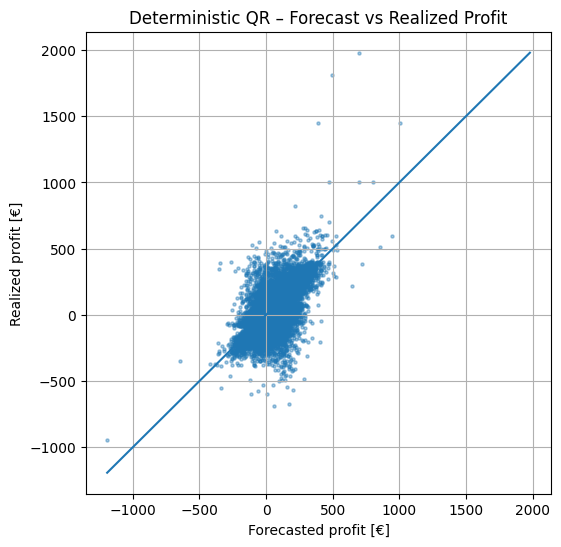

In [3]:
from src.analysis.ip_results import (
    profit_summary_for_scenario,
    infer_perfect_foresight_path,
    plot_forecast_vs_realized,
)

scenario = PROJECT_ROOT / "results/ip_rolling_ce/ip_rolling_ce_qr_deterministic_forecast_TP_L1_0.1_CP_0__v1.parquet"
pf = infer_perfect_foresight_path(scenario)

series, totals, meta = profit_summary_for_scenario(scenario, perfect_foresight_path=pf)

plot_forecast_vs_realized(
    series,
    title="Deterministic QR – Forecast vs Realized Profit"
)


<Axes: title={'center': 'QR–CVaR(0.95, λ=0.1) – Forecast vs Realized Profit'}, xlabel='Forecasted profit [€]', ylabel='Realized profit [€]'>

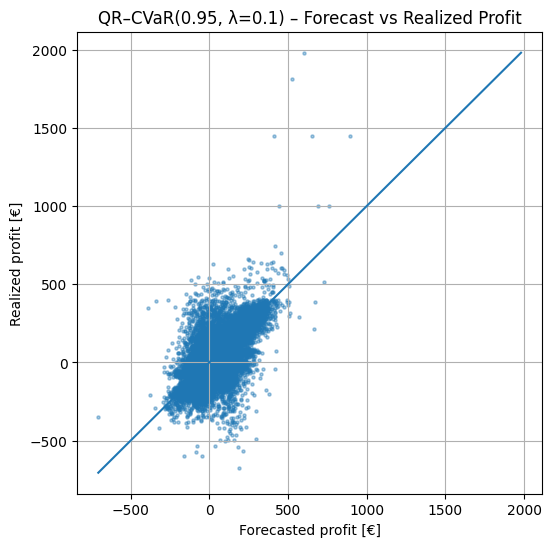

In [4]:
from src.analysis.ip_results import profit_summary_for_scenario, plot_forecast_vs_realized

p = PROJECT_ROOT / "results/ip_rolling_prob/ip_rolling_prob_qr_quantile_paths_cvar_a0p95_l0p1_TP_L1_0.1_CP_0_v1.parquet"

series_p, totals_p, meta_p = profit_summary_for_scenario(p)

plot_forecast_vs_realized(
    series_p,
    title="QR–CVaR(0.95, λ=0.1) – Forecast vs Realized Profit"
)


In [5]:

# --- paths ---
det_path = PROJECT_ROOT / "results/ip_rolling_ce/ip_rolling_ce_qr_deterministic_forecast_TP_L1_0.1_CP_0__v1.parquet"
pf_path = infer_perfect_foresight_path(det_path)  # deterministic perfect foresight (upper bound for ALL)

prob_dir = PROJECT_ROOT / "results/ip_rolling_prob"
prob_paths = sorted(prob_dir.glob("*.parquet"))

# --- load perfect foresight realized profit series once ---
pf_series, pf_totals, _ = profit_summary_for_scenario(pf_path)  # no need to pass perfect_foresight_path here
pf_real = pf_series.realized.rename("perfect_foresight_realized")

# --- helper: align any realized series to PF timestamps (important!) ---
def align_to_pf(s: pd.Series, pf_index: pd.DatetimeIndex) -> pd.Series:
    # inner join on timestamps
    s = s.copy()
    s = s.loc[s.index.intersection(pf_index)]
    return s

# --- collect strategies ---
strategies = []

# deterministic forecast
det_series, det_totals, _ = profit_summary_for_scenario(det_path, perfect_foresight_path=pf_path)
det_real = align_to_pf(det_series.realized, pf_real.index)
strategies.append({
    "label": "deterministic_TP_L1_0.1",
    "realized": det_real,
    "forecast_total": det_totals.forecast_total_eur,
    "realized_total": float(det_real.fillna(0.0).sum()),
})

# probabilistic ones (CVaR, RN, etc.)
for p in prob_paths:
    s, totals, _ = profit_summary_for_scenario(p)  # no optimal inside; we use pf_real as UB
    real = align_to_pf(s.realized, pf_real.index)
    strategies.append({
        "label": p.stem.replace("ip_rolling_prob_", ""),  # shorter label
        "realized": real,
        "forecast_total": totals.forecast_total_eur,
        "realized_total": float(real.fillna(0.0).sum()),
    })

# Perfect foresight totals on the same index used for each strategy
# (we compute regret per-strategy on matched timestamps)
for d in strategies:
    idx = d["realized"].index
    d["pf_total"] = float(pf_real.loc[idx].fillna(0.0).sum())
    d["regret_eur"] = d["pf_total"] - d["realized_total"]

summary = pd.DataFrame([{
    "strategy": d["label"],
    "realized_total_eur": d["realized_total"],
    "pf_total_eur": d["pf_total"],
    "regret_eur": d["regret_eur"],
} for d in strategies]).sort_values("regret_eur", ascending=True)

summary


,strategy,realized_total_eur,pf_total_eur,regret_eur
4,qr_quantile_paths_rn_TP_L1_0.1_CP_0_v1,1.242717e+06,2.600870e+06,1.358152e+06
2,qr_quantile_paths_cvar_a0p95_l0p3_TP_L1_0.1_CP...,1.238003e+06,2.600870e+06,1.362866e+06
1,qr_quantile_paths_cvar_a0p95_l0p1_TP_L1_0.1_CP...,1.236725e+06,2.600870e+06,1.364144e+06
3,qr_quantile_paths_cvar_a0p95_l0p5_TP_L1_0.1_CP...,1.223886e+06,2.600870e+06,1.376984e+06
0,deterministic_TP_L1_0.1,1.207037e+06,2.600870e+06,1.393833e+06


In [6]:
# Order by regret (best on top)
plot_df = summary.sort_values("regret_eur", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["strategy"], plot_df["regret_eur"])
ax.set_xlabel("Regret vs perfect foresight [€]  (lower is better)")
ax.set_title("Regret comparison: deterministic vs probabilistic (CVaR etc.)")
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

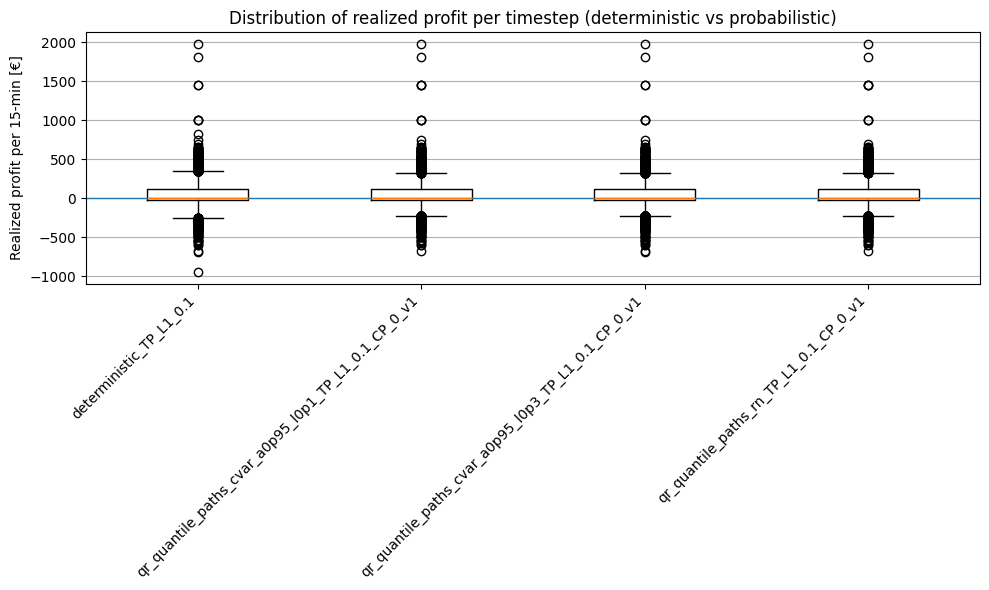

In [ ]:
labels = [d["label"] for d in strategies]
data = [d["realized"].dropna().values for d in strategies]

fig, ax = plt.subplots(figsize=(max(10, 0.5*len(labels)), 6))

parts = ax.boxplot(
    data,
    showmeans=False,
)

ax.set_xticks(np.arange(1, len(labels)+1))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Realized profit per 15-min [€]")
ax.set_title("Distribution of realized profit per timestep (deterministic vs probabilistic)")

# Optional: add a horizontal line at 0 (break-even)
ax.axhline(0.0, linewidth=1)
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()
